<a href="https://colab.research.google.com/github/anjuts006/ict_assignments/blob/main/CaseStudy1_Anju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df =  pd.read_csv('/content/athlete_events - medal.csv')
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246859,123601,Nataliya Andreyevna Ustinova,F,19.0,165.0,58.0,Soviet Union,URS,1964 Summer,1964.0,Summer,Tokyo,Swimming,Swimming Women's 4 x 100 metres Medley Relay,Bronze
246860,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 100 metres Freestyle,NaN
246861,123601,Nataliya Andreyevna Ustinova,F,23.0,165.0,58.0,Soviet Union,URS,1968 Summer,1968.0,Summer,Mexico City,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,NaN
246862,123602,Tetiana Illivna Ustiuzhanina,F,27.0,185.0,78.0,Unified Team,EUN,1992 Summer,1992.0,Summer,Barcelona,Rowing,Rowing Women's Quadruple Sculls,Bronze


**PART 1 — Data Understanding**


Q1. Load the dataset.


In [59]:
df.head()  #first 5 rows

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992.0,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012.0,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920.0,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988.0,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [60]:
df.shape # number of columns and rows

(246864, 15)

In [61]:
print(df.columns)  #displaying column names

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')


Q2. Check data types.


In [62]:
df.dtypes

,0
ID,int64
Name,object
Sex,object
Age,float64
Height,float64
Weight,float64
Team,object
NOC,object
Games,object
Year,float64


In [63]:
num = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
print(num)

Numerical columns:
Index(['ID', 'Age', 'Height', 'Weight', 'Year'], dtype='object')


In [64]:
cat = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:")
print(cat)

Categorical columns:
Index(['Name', 'Sex', 'Team', 'NOC', 'Games', 'Season', 'City', 'Sport',
       'Event', 'Medal'],
      dtype='object')


Q3. Missing Values


In [65]:
df.isnull().sum()


,0
ID,0
Name,0
Sex,0
Age,8667
Height,54813
Weight,57347
Team,0
NOC,0
Games,0
Year,1


In [66]:
df['Medal'].unique()

array([nan, 'Gold', 'Bronze', 'Silver'], dtype=object)

**PART 2 — Medal Filtering**


Q4. Create a new DataFrame containing only medal winners.


In [67]:
medal_winners_df = df.dropna(subset=['Medal'])


In [68]:
display(medal_winners_df.head())

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900.0,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
37,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
38,15,Arvo Ossian Aaltonen,M,30.0,NaN,NaN,Finland,FIN,1920 Summer,1920.0,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014.0,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948.0,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze


**PART 3 — Country Analysis**

Q5. Total Medal Count


In [70]:
top_10_countries = (
    medal_winners_df.groupby('NOC')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_10_countries)

NOC
USA    5161
URS    2271
GBR    1904
GER    1883
FRA    1714
ITA    1530
SWE    1433
CAN    1239
AUS    1219
HUN    1048
dtype: int64


Q6. Visualize Top 10 Countries


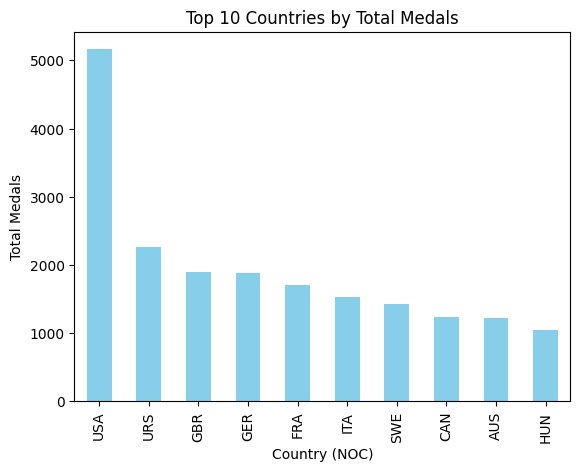

In [73]:
top_10_countries.plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Total Medals')
plt.show()

Q7. Gold Medal Analysis


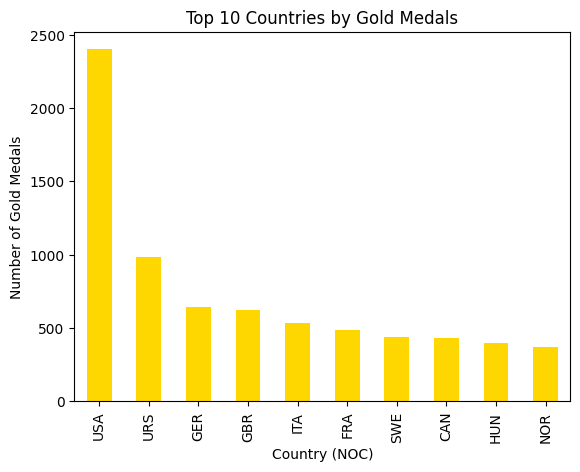

In [78]:
gold = medal_winners_df[medal_winners_df['Medal'] == 'Gold']
top_gold = gold['NOC'].value_counts().head(10)
top_gold.plot(kind='bar', color='gold')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Country (NOC)')
plt.ylabel('Number of Gold Medals')
plt.show()

**PART 4 — Gender Analysis**

Q8. Gender Distribution


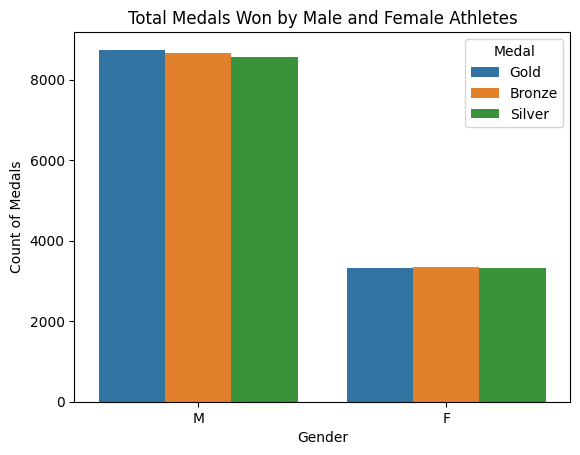

In [86]:
sns.countplot(data=medal_winners_df, x='Sex', hue='Medal')
plt.title('Total Medals Won by Male and Female Athletes')
plt.xlabel('Gender')
plt.ylabel('Count of Medals')

plt.show()

Q9. Gender Trend Over Years



In [88]:
medal_counts = df.groupby(['Year', 'Sex']).size().reset_index(name='Medal_Count')
medal_counts.head()

,Year,Sex,Medal_Count
0,1896.0,M,348
1,1900.0,F,32
2,1900.0,M,1764
3,1904.0,F,13
4,1904.0,M,1146


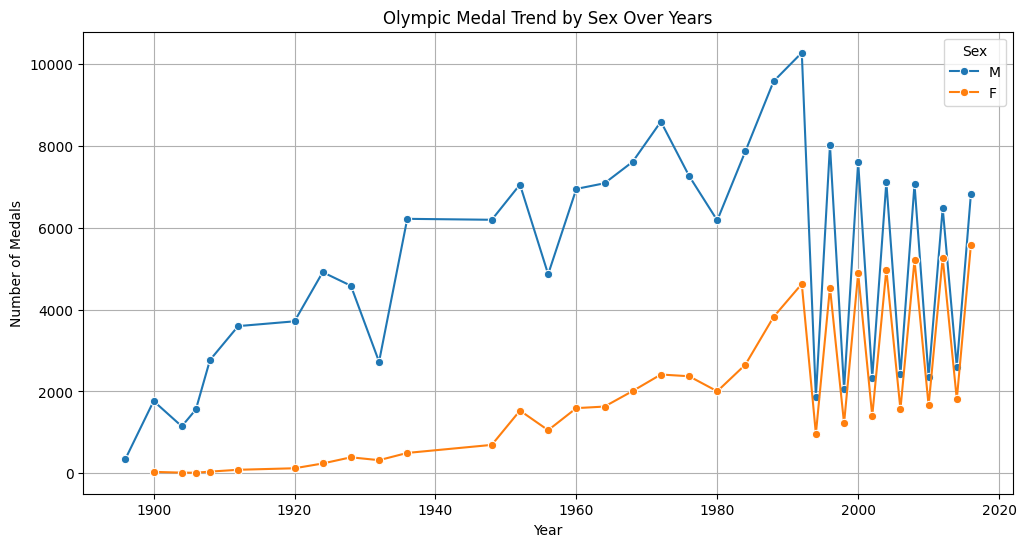

In [89]:
plt.figure(figsize=(12,6))
sns.lineplot(data=medal_counts, x='Year', y='Medal_Count', hue='Sex', marker='o')

plt.title('Olympic Medal Trend by Sex Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.show()

**PART 5 — Sport Analysis**


Q10. Top Sports

In [94]:

sport_sex_counts = df.groupby(['Sport', 'Sex']).size().reset_index(name='Medal_Count')
top_sports = sport_sex_counts.groupby('Sport')['Medal_Count'].sum().sort_values(ascending=False).head(10).index
top_sport_sex = sport_sex_counts[sport_sex_counts['Sport'].isin(top_sports)]

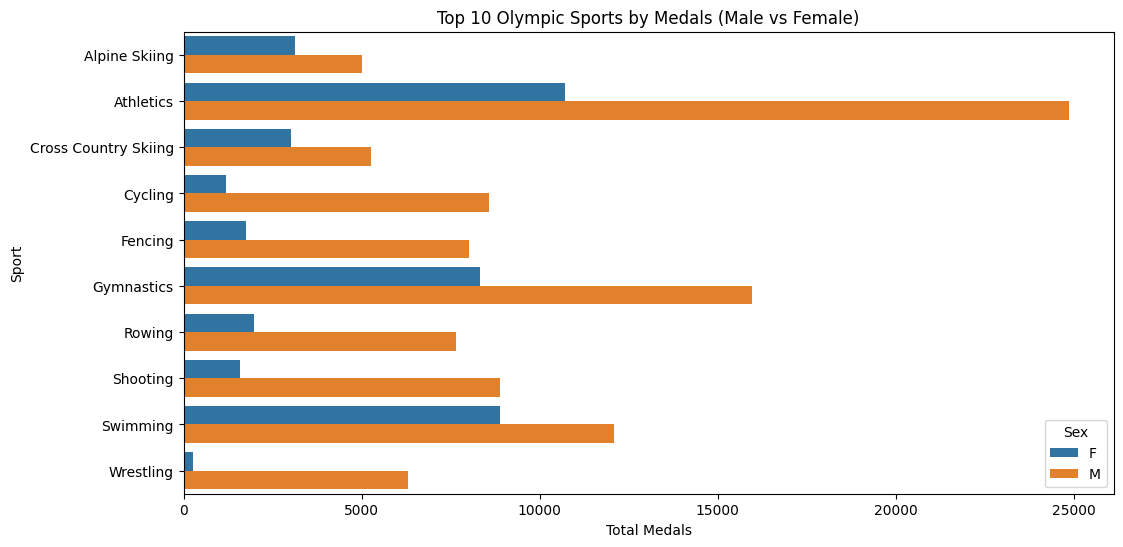

In [95]:
plt.figure(figsize=(12,6))
sns.barplot(data=top_sport_sex, x='Medal_Count', y='Sport', hue='Sex')
plt.title('Top 10 Olympic Sports by Medals (Male vs Female)')
plt.xlabel('Total Medals')
plt.ylabel('Sport')
plt.legend(title='Sex')
plt.show()

Q11. Gold Medal Sport


In [96]:
gold_medals = df[df['Medal'] == 'Gold']
gold_counts = gold_medals.groupby('Sport').size().reset_index(name='Gold_Medals')
top_gold_sport = gold_counts.sort_values(by='Gold_Medals', ascending=False).head(1)
top_gold_sport

,Sport,Gold_Medals
5,Athletics,1230


**PART 6 — Year-wise Analysis**

Q12. Medal Trend Over Time


In [97]:
medals_per_year = df.groupby('Year').size().reset_index(name='Total_Medals')
medals_per_year.head()

,Year,Total_Medals
0,1896.0,348
1,1900.0,1796
2,1904.0,1159
3,1906.0,1569
4,1908.0,2805


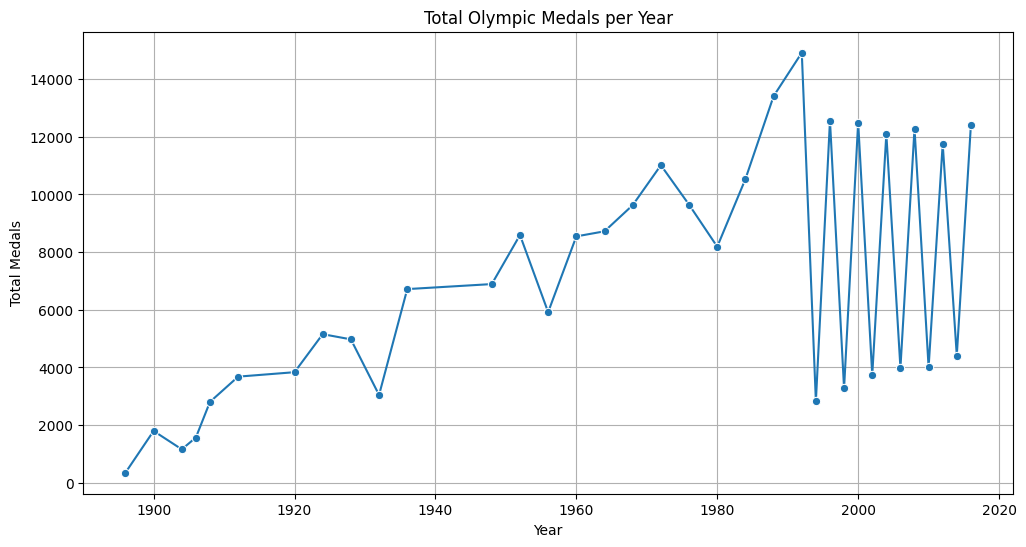

In [98]:
plt.figure(figsize=(12,6))
sns.lineplot(data=medals_per_year, x='Year', y='Total_Medals', marker='o')
plt.title('Total Olympic Medals per Year')
plt.xlabel('Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.show()

Q13. Best Olympic Year



In [99]:
medals_per_year = df.groupby('Year').size().reset_index(name='Total_Medals')
max_medals_year = medals_per_year.loc[medals_per_year['Total_Medals'].idxmax()]
max_medals_year

,22
Year,1992.0
Total_Medals,14913.0


**PART 7 — Age Analysis**

Q14. Age Distribution


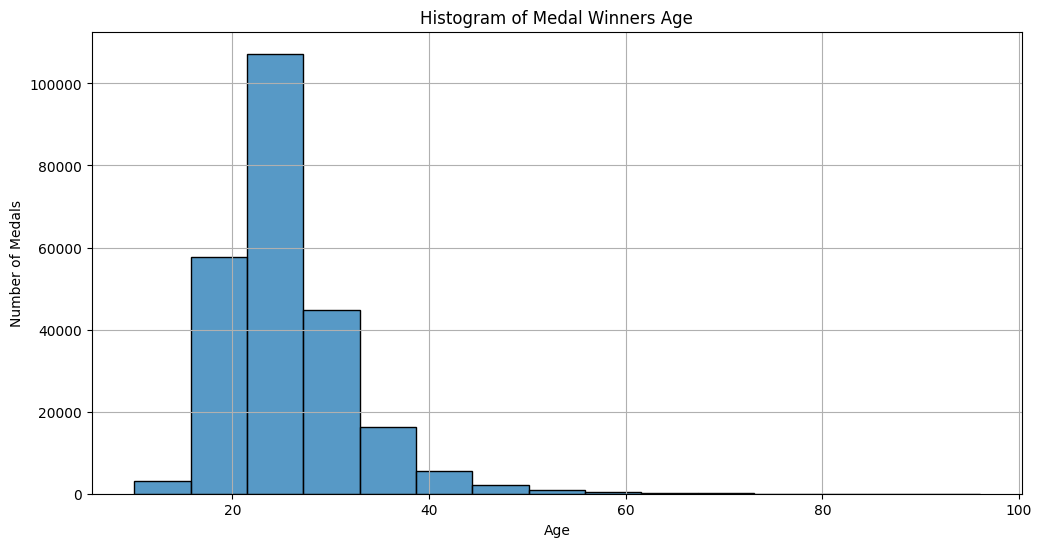

In [100]:
plt.figure(figsize=(12,6))
sns.histplot(df['Age'].dropna(), bins=15, kde=False)
plt.title('Histogram of Medal Winners Age')
plt.xlabel('Age')
plt.ylabel('Number of Medals')
plt.grid(True)
plt.show()

In [101]:
age_counts = pd.cut(df['Age'], bins=15).value_counts().sort_values(ascending=False)
most_common_age_range = age_counts.index[0]
print("Most common winning age range:", most_common_age_range)

Most common winning age range: (21.467, 27.2]


Q15. Average Age by Medal Type


In [104]:
medalists = df[df['Medal'].notna()]
average_ages = medalists.groupby('Medal')['Age'].mean()
average_ages

,Age
Medal,
Bronze,25.902074
Gold,25.906690
Silver,26.027022


**PART 8 — Correlation & Numerical Insight**

Q16. Correlation Matrix


In [105]:
num_cols = df[['Age', 'Height', 'Weight']].dropna()
corr_matrix = num_cols.corr()
corr_matrix

,Age,Height,Weight
Age,1.000000,0.141762,0.211581
Height,0.141762,1.000000,0.795940
Weight,0.211581,0.795940,1.000000


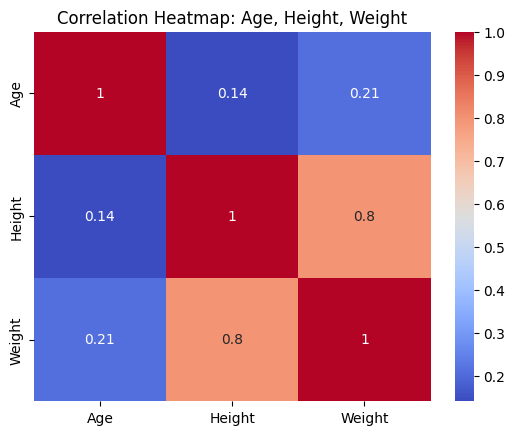

In [106]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap: Age, Height, Weight")
plt.show()

**PART 9 — Mini Investigation (Open-Ended)**


Q17. Country Performance


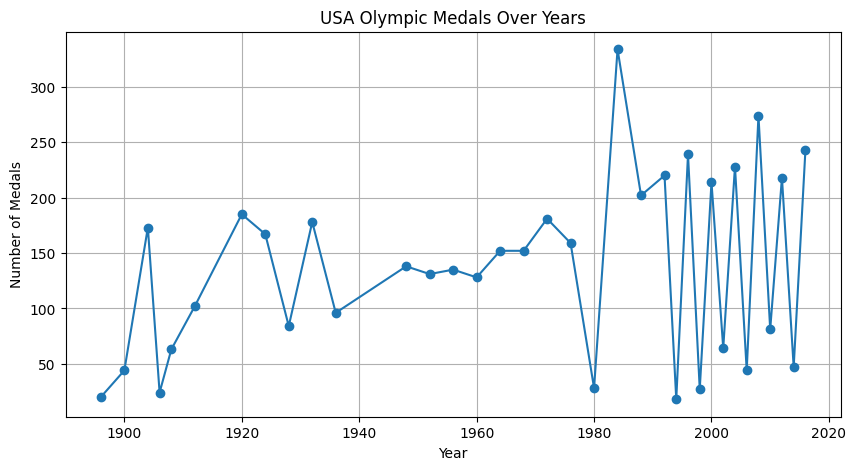

In [107]:
usa_medals = df[(df['Team'] == 'United States') & (df['Medal'].notna())]
medal_trend = usa_medals.groupby('Year')['Medal'].count()
plt.figure(figsize=(10,5))
medal_trend.plot(marker='o')
plt.title("USA Olympic Medals Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Medals")
plt.grid(True)
plt.show()

Q18. Sport Deep Dive


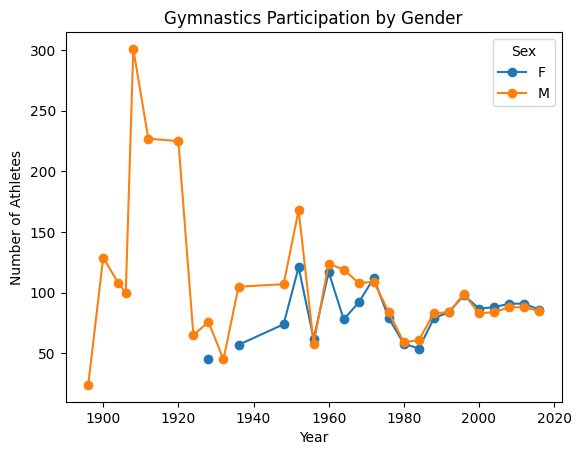

In [108]:
gym = df[df['Sport'] == 'Gymnastics']
gender_trend = gym.groupby(['Year', 'Sex'])['ID'].nunique().unstack()
gender_trend.plot(marker='o')
plt.title("Gymnastics Participation by Gender")
plt.xlabel("Year")
plt.ylabel("Number of Athletes")
plt.show()

 **BONUS (Optional)**

Q19. Top 5 Youngest Gold Medalists


In [109]:
gold_medalists = df[(df['Medal'] == 'Gold') & (df['Age'].notna())]
youngest_gold = gold_medalists.sort_values(by='Age').head(5)
youngest_gold[['Name', 'Age', 'Team', 'Sport', 'Event', 'Year']]

,Name,Age,Team,Sport,Event,Year
78544,Marjorie Gestring (-Redlick),13.0,United States,Diving,Diving Women's Springboard,1936.0
73581,Fu Mingxia,13.0,China,Diving,Diving Women's Platform,1992.0
52010,Donna Elizabeth de Varona (-Pinto),13.0,United States,Swimming,Swimming Women's 4 x 100 metres Freestyle Relay,1960.0
200704,Aileen Muriel Riggin (-Soule),13.0,United States,Diving,Diving Women's Springboard,1920.0
119277,Kim Yun-Mi,13.0,South Korea,Short Track Speed Skating,"Short Track Speed Skating Women's 3,000 metres...",1994.0


Q20. Medal Ratio


In [111]:
medalists = df[df['Medal'].notna()]
total_medals = medalists.groupby('Team')['Medal'].count()
gold_medals = medalists[medalists['Medal'] == 'Gold'].groupby('Team')['Medal'].count()
medal_ratio = pd.DataFrame({
    'Total': total_medals,
    'Gold': gold_medals
}).fillna(0)

medal_ratio['Gold_Ratio'] = medal_ratio['Gold'] / medal_ratio['Total']
top5 = medal_ratio.sort_values('Total', ascending=False).head(5)
top5

,Total,Gold,Gold_Ratio
Team,,,
United States,4793,2264.0,0.472356
Soviet Union,2226,965.0,0.433513
Germany,1723,586.0,0.340104
Great Britain,1545,477.0,0.308738
France,1497,442.0,0.295257
